<a href="https://colab.research.google.com/github/pedrosampaiom2007-gif/CP2-SERS/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [ ]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [ ]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [ ]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [ ]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [ ]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [ ]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
# Algoritmos do sklearn para classificação
from sklearn.linear_model import LogisticRegression # Prever número regressao
from sklearn.tree import DecisionTreeClassifier # Prever classificação
from sklearn.ensemble import RandomForestClassifier # Prever classificação
from sklearn.neighbors import KNeighborsClassifier # Prever classificação
# Separação dos dados de treino e teste

from sklearn.model_selection import train_test_split

#X_train,X_test,y_train,Y_test

# treinar modelo usa o fit (X_train, Y_train)

# Métricas para classificação

from sklearn.metrics import accuracy_score # acurácia
from sklearn.metrics import confusion_matrix # identificação de onde o modelo errou
from sklearn.metrics import classification_report #Resumo de métricas

In [ ]:
dados_cp=pd.read_csv("https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv")
dados_cp.head() # Carregando os dados

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


In [ ]:
dados_cp.isnull().sum() # Verificando se há valores ausentes

,0
potencia_kw,0
latitude,0
longitude,0
fonte,0


In [ ]:
dados_cp.info() # Verificando o tipo de dado dos valores das colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [ ]:
dados_cp["fonte"].unique() # Verificando os valores únicos da coluna fonte

array(['Solar', 'Eólica', 'Hidráulica'], dtype=object)

In [ ]:
dados_cp["fonte"].value_counts() # Verificando a quantidade de valores únicos da coluna fonte (target)

,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


In [ ]:
dados_cp.describe()# Verificando dados estatísticos

,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000


In [ ]:
dados_cp[["potencia_kw","latitude","longitude"]].value_counts()

potencia_kw  latitude    longitude 
37200.0       0.000000    0.000000     5
1000.0        0.000000    0.000000     4
30000.0      -9.531903   -40.487846    4
50400.0       0.000000    0.000000     4
2000.0        0.000000    0.000000     3
                                      ..
1250.0       -22.570464  -46.409941    1
1260.0       -21.017222  -42.440833    1
             -21.013985  -42.460709    1
             -20.865278  -42.355000    1
1200.0       -26.798889  -51.950278    1
Name: count, Length: 3848, dtype: int64

In [ ]:
dados_treino=dados_cp[["potencia_kw","latitude","longitude"]]# atributos de entrada usados pra treino

In [ ]:
x=dados_treino
y=dados_cp["fonte"]# atributo de previsão

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)
#

In [ ]:
modelo_lr=LogisticRegression()#regressão logística
modelo_lr.fit(x_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
modelo_knn=KNeighborsClassifier()# knn vizinhos mais próximos
modelo_knn.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
modelo_random=RandomForestClassifier()# floresta aleatória
modelo_random.fit(x_train,y_train)#treinando o modelo

RandomForestClassifier()

In [ ]:
y_knn=modelo_knn.predict(x_test)
y_lr=modelo_lr.predict(x_test)
y_random=modelo_random.predict(x_test)

In [ ]:
acuracia_lr= accuracy_score(y_test,y_lr)
acuracia_knn= accuracy_score(y_test,y_knn)
acuracia_random= accuracy_score(y_test,y_random)
acuracia_lr,acuracia_knn,acuracia_random

(0.7132258064516129, 0.8061290322580645, 0.9551612903225807)

In [ ]:
print("--- Métricas para Regressão Logística ---")
print(classification_report(y_test, y_lr, zero_division=0))
print("Matriz de Confusão para Regressão Logística:")
print(confusion_matrix(y_test, y_lr))

print("\n--- Métricas para K-Nearest Neighbors (KNN) ---")
print(classification_report(y_test, y_knn, zero_division=0))
print("Matriz de Confusão para K-Nearest Neighbors (KNN):")
print(confusion_matrix(y_test, y_knn))

print("\n--- Métricas para Random Forest ---")
print(classification_report(y_test, y_random, zero_division=0))
print("Matriz de Confusão para Random Forest:")
print(confusion_matrix(y_test, y_random))

--- Métricas para Regressão Logística ---
              precision    recall  f1-score   support

      Eólica       0.64      0.66      0.65       960
  Hidráulica       0.75      0.80      0.78      1180
       Solar       0.74      0.65      0.70       960

    accuracy                           0.71      3100
   macro avg       0.71      0.71      0.71      3100
weighted avg       0.71      0.71      0.71      3100

Matriz de Confusão para Regressão Logística:
[[634 206 120]
 [132 949  99]
 [226 106 628]]

--- Métricas para K-Nearest Neighbors (KNN) ---
              precision    recall  f1-score   support

      Eólica       0.69      0.78      0.73       960
  Hidráulica       0.86      0.84      0.85      1180
       Solar       0.88      0.79      0.83       960

    accuracy                           0.81      3100
   macro avg       0.81      0.80      0.81      3100
weighted avg       0.81      0.81      0.81      3100

Matriz de Confusão para K-Nearest Neighbors (KNN):
[[750

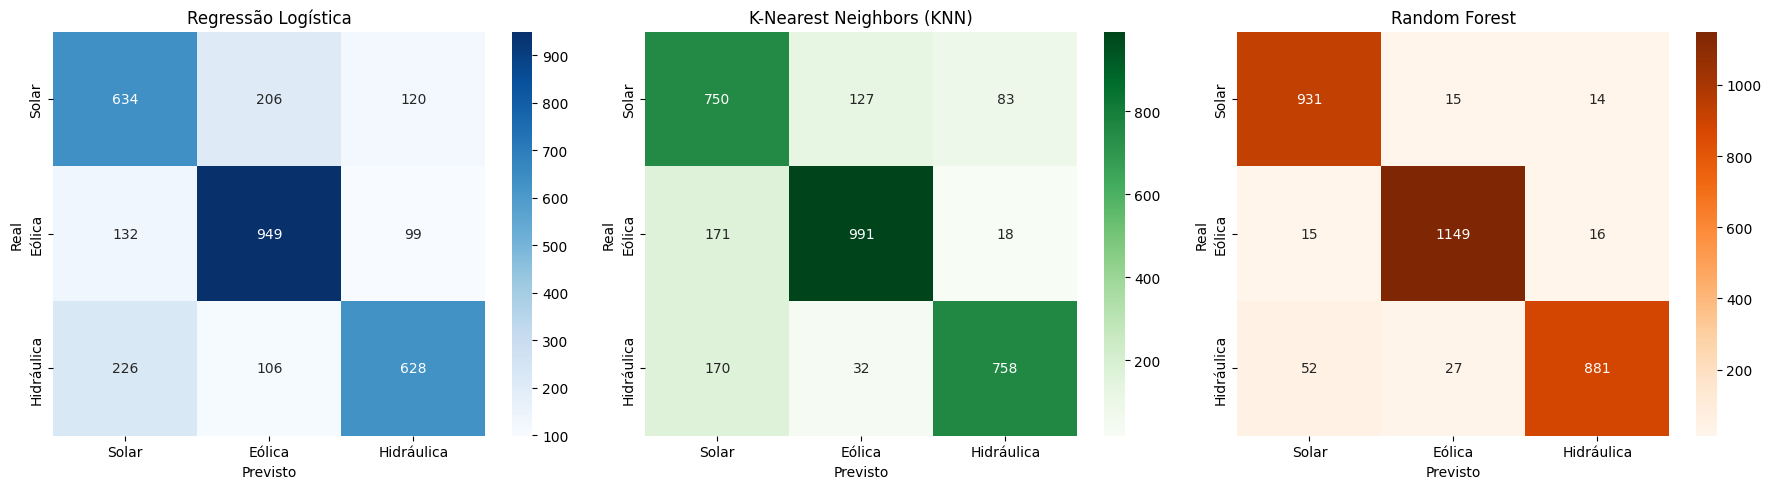

In [ ]:
plt.figure(figsize=(18, 5))

# Matriz de Confusão para Regressão Logística
plt.subplot(1, 3, 1)
sns.heatmap(confusion_matrix(y_test, y_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=y.unique(), yticklabels=y.unique())
plt.title('Regressão Logística')
plt.xlabel('Previsto')
plt.ylabel('Real')

# Matriz de Confusão para K-Nearest Neighbors (KNN)
plt.subplot(1, 3, 2)
sns.heatmap(confusion_matrix(y_test, y_knn), annot=True, fmt='d', cmap='Greens',
            xticklabels=y.unique(), yticklabels=y.unique())
plt.title('K-Nearest Neighbors (KNN)')
plt.xlabel('Previsto')
plt.ylabel('Real')

# Matriz de Confusão para Random Forest
plt.subplot(1, 3, 3)
sns.heatmap(confusion_matrix(y_test, y_random), annot=True, fmt='d', cmap='Oranges',
            xticklabels=y.unique(), yticklabels=y.unique())
plt.title('Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.tight_layout()
plt.show()

Com base na análise, o **Random Forest** é o melhor modelo (acurácia ~0.96). Ele mais confunde a categoria Hidráulica, principalmente com Solar (52 instâncias) e Eólica (27 instâncias).

**Por que potência/localização podem não bastar para uma aplicação real:**

Embora úteis, `potencia_kw`, `latitude` e `longitude` são limitadas porque não capturam detalhes como:

1.  **Variações regionais e microclima:** Topografia, microclimas, ou recursos específicos (vento, água, sol) não são totalmente representados por coordenadas gerais.
2.  **Tecnologia e eficiência:** Diferenças na tecnologia de geração (ex: tipos de painéis solares) afetam o desempenho mas não são visíveis nos dados.
3.  **Fatores regulatórios e infraestrutura:** Licenças, leis ou proximidade com redes de transmissão são cruciais na escolha da fonte, mas ausentes nos dados.
4.  **Dados históricos de geração:** A potência outorgada é nominal; a geração real ao longo do tempo seria um preditor mais rico.

Para uma aplicação robusta, seria ideal complementar com dados mais contextuais e detalhados.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [3]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [7]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

NameError: name 'consultar_api' is not defined

### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [ ]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [ ]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine Learning
# Algoritmos do sklearn para regressão
from sklearn.linear_model import LinearRegression # Regressão linear
from sklearn.tree import DecisionTreeRegressor # Árvore de decisão
from sklearn.ensemble import RandomForestRegressor # Floresta aleatória

# Métricas para regressão
from sklearn.metrics import mean_absolute_error # MAE
from sklearn.metrics import mean_squared_error # MSE
from sklearn.metrics import r2_score # R²

In [8]:
dados_regressao = pd.read_csv("meteo_regressao_orange.csv")
dados_regressao.head() # Carregando os dados

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0


In [9]:
dados_regressao.isnull().sum() # Verificando se há valores ausentes

,0
data_hora,0
temperatura_c,0
umidade_pct,0
nuvens_pct,0
vento_kmh,0
hora,0
radiacao_w_m2,0


In [10]:

dados_regressao.info() # Verificando o tipo de dado dos valores das colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.9+ KB


In [11]:
dados_regressao.describe() # Verificando os dados estatísticos

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000


In [12]:
dados_regressao["hora"].unique() # Verificando os valores da coluna hora

array([ 7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [13]:
dados_regressao["radiacao_w_m2"].value_counts() # Verificando os valores da radiação

,count
radiacao_w_m2,
117.0,7
365.0,6
381.0,5
123.0,5
124.0,5
...,...
140.0,1
303.0,1
750.0,1


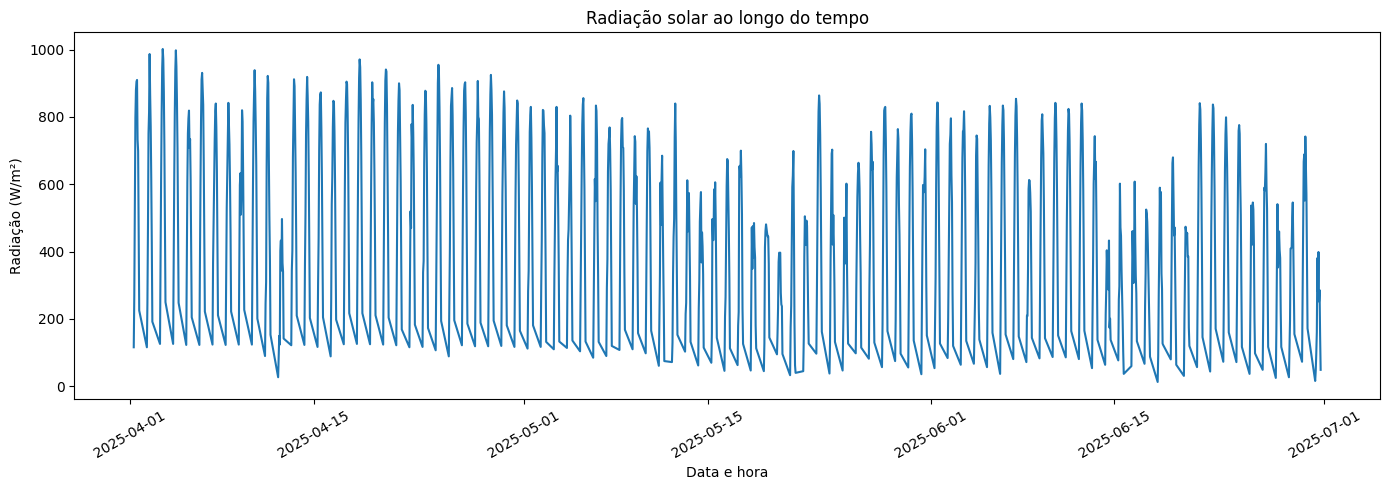

In [14]:
dados_regressao["data_hora"] = pd.to_datetime(dados_regressao["data_hora"])
dados_regressao = dados_regressao.sort_values("data_hora").reset_index(drop=True)

# Visualização simples da radiação ao longo do tempo
plt.figure(figsize=(14, 5))
plt.plot(dados_regressao["data_hora"], dados_regressao["radiacao_w_m2"])
plt.title("Radiação solar ao longo do tempo")
plt.xlabel("Data e hora")
plt.ylabel("Radiação (W/m²)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [15]:
dados_treino = dados_regressao[["temperatura_c", "umidade_pct",
                                  "nuvens_pct", "vento_kmh", "hora"]]
# atributos de entrada usados para treino

In [16]:
x = dados_treino
y = dados_regressao["radiacao_w_m2"] # atributo de previsão

In [17]:
# Mantendo a ordem das horas: 80% primeiras para treino e 20% finais para teste
corte = int(len(dados_regressao) * 0.8)

x_train = x.iloc[:corte]
x_test = x.iloc[corte:]
y_train = y.iloc[:corte]
y_test = y.iloc[corte:]

print("Treino:", len(x_train))
print("Teste:", len(x_test))
print("Primeira data de teste:", dados_regressao["data_hora"].iloc[corte])

Treino: 800
Teste: 201
Primeira data de teste: 2025-06-12 15:00:00


In [18]:
modelo_lr = LinearRegression() # Regressão linear
modelo_lr.fit(x_train, y_train)

LinearRegression()

In [19]:
modelo_arvore = DecisionTreeRegressor(random_state=42) # Árvore de decisão
modelo_arvore.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [20]:
modelo_random = RandomForestRegressor(random_state=42) # Floresta aleatória
modelo_random.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [21]:
y_lr = modelo_lr.predict(x_test)
y_arvore = modelo_arvore.predict(x_test)
y_random = modelo_random.predict(x_test)

In [22]:
mae_lr = mean_absolute_error(y_test, y_lr)
mse_lr = mean_squared_error(y_test, y_lr)
r2_lr = r2_score(y_test, y_lr)

mae_arvore = mean_absolute_error(y_test, y_arvore)
mse_arvore = mean_squared_error(y_test, y_arvore)
r2_arvore = r2_score(y_test, y_arvore)

mae_random = mean_absolute_error(y_test, y_random)
mse_random = mean_squared_error(y_test, y_random)
r2_random = r2_score(y_test, y_random)

print("--- Métricas para Regressão Linear ---")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("R²:", r2_lr)

print("\n--- Métricas para Árvore de Decisão ---")
print("MAE:", mae_arvore)
print("MSE:", mse_arvore)
print("R²:", r2_arvore)

print("\n--- Métricas para Random Forest ---")
print("MAE:", mae_random)
print("MSE:", mse_random)
print("R²:", r2_random)

--- Métricas para Regressão Linear ---
MAE: 145.2048850741199
MSE: 30034.201092064613
R²: 0.35984495652041326

--- Métricas para Árvore de Decisão ---
MAE: 88.7910447761194
MSE: 15291.1592039801
R²: 0.6740811365325959

--- Métricas para Random Forest ---
MAE: 66.80417910447761
MSE: 7307.417901492537
R²: 0.8442482152225645


In [23]:
resultados = pd.DataFrame({
    "Modelo": ["Regressão Linear", "Árvore de Decisão", "Random Forest"],
    "MAE": [mae_lr, mae_arvore, mae_random],
    "MSE": [mse_lr, mse_arvore, mse_random],
    "R²": [r2_lr, r2_arvore, r2_random]
})

resultados.round(3)

,Modelo,MAE,MSE,R²
0,Regressão Linear,145.205,30034.201,0.360
1,Árvore de Decisão,88.791,15291.159,0.674
2,Random Forest,66.804,7307.418,0.844


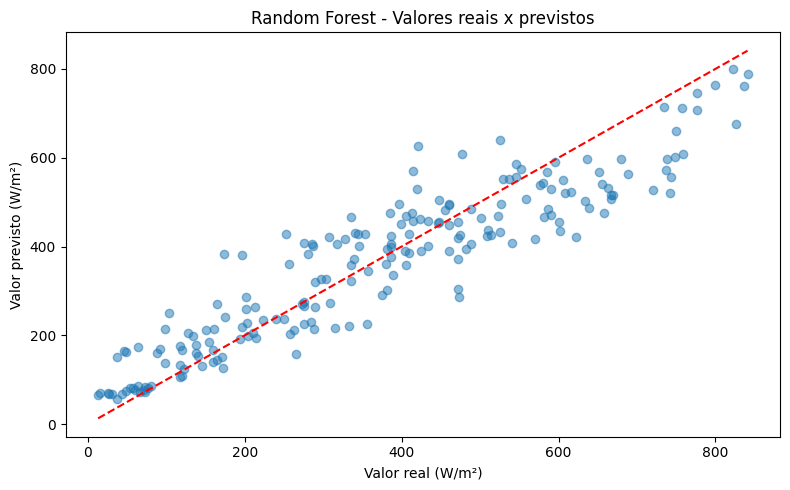

In [24]:
# Gráfico de valores reais x previstos
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_random, alpha=0.5)
plt.xlabel("Valor real (W/m²)")
plt.ylabel("Valor previsto (W/m²)")
plt.title("Random Forest - Valores reais x previstos")

limite_min = min(y_test.min(), y_random.min())
limite_max = max(y_test.max(), y_random.max())
plt.plot([limite_min, limite_max], [limite_min, limite_max], "r--")

plt.tight_layout()
plt.show()

In [25]:
print("Resultados da Regressão Linear:")
print("MAE:", round(mae_lr, 2))
print("MSE:", round(mse_lr, 2))
print("R²:", round(r2_lr, 3))

print("\nResultados da Árvore de Decisão:")
print("MAE:", round(mae_arvore, 2))
print("MSE:", round(mse_arvore, 2))
print("R²:", round(r2_arvore, 3))

print("\nResultados do Random Forest:")
print("MAE:", round(mae_random, 2))
print("MSE:", round(mse_random, 2))
print("R²:", round(r2_random, 3))

print("\nA coluna hora é importante porque a radiação varia ao longo do dia.")
print("A radiação também é influenciada pelas condições meteorológicas, como a cobertura de nuvens.")
print("A previsão da radiação não significa diretamente a energia produzida por um sistema fotovoltaico,")
print("pois a geração também depende de fatores como potência dos painéis, eficiência, área, orientação e perdas.")

Resultados da Regressão Linear:
MAE: 145.2
MSE: 30034.2
R²: 0.36

Resultados da Árvore de Decisão:
MAE: 88.79
MSE: 15291.16
R²: 0.674

Resultados do Random Forest:
MAE: 66.8
MSE: 7307.42
R²: 0.844

A coluna hora é importante porque a radiação varia ao longo do dia.
A radiação também é influenciada pelas condições meteorológicas, como a cobertura de nuvens.
A previsão da radiação não significa diretamente a energia produzida por um sistema fotovoltaico,
pois a geração também depende de fatores como potência dos painéis, eficiência, área, orientação e perdas.


# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)